#  Forecasting Demand Analysis for Global Health Commodities

## Description

This notebook supports a research project focused on analyzing and forecasting logistics costs within donor-funded health supply chains, specifically for ARV and HIV-related commodities. It integrates **exploratory data analysis**, **traditional modeling**, **machine learning**, and **deep learning** to evaluate shipment efficiency and cost behavior across multiple dimensions.

##  Workflow Overview

1. **Data Loading and Preprocessing**
   - Import cleaned shipment data provided by USAID
   - Feature engineering: create total cost, cost per unit, shipment category features
   - Handle missing values and encode categorical variables

2. **Exploratory Data Analysis (EDA)**
   - Analyze shipment demand by country, mode, and product group
   - Identify shipment patterns, outliers, and high-cost routes
   - Correlation analysis between quantity, cost, and value

3. **Modeling and Forecasting**
   - Predict logistics cost using:
     -  Statiscal modeling
     - Random Forest
     - LSTM (Deep Learning)
   - Compare models using RMSE, MAE, WMAPE

4. **Insights and Recommendations**
   - Support data-driven supply chain decisions using model outputs

## Goal

To compare forecasting performance across modeling techniques and derive practical insights.

---


# I. Import libraries and dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("Suppy_Chain_Shipment_Data.csv")
df.head()

,id,project code,pq #,po / so #,asn/dn #,country,managed by,fulfill via,vendor inco term,shipment mode,...,unit of measure (per pack),line item quantity,line item value,pack price,unit price,manufacturing site,first line designation,weight (kilograms),freight cost (usd),line item insurance (usd)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,True,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",True,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,True,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",True,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",True,7590,45450.08,NaN


# II. EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            10324 non-null  int64  
 1   project code                  10324 non-null  object 
 2   pq #                          10324 non-null  object 
 3   po / so #                     10324 non-null  object 
 4   asn/dn #                      10324 non-null  object 
 5   country                       10324 non-null  object 
 6   managed by                    10324 non-null  object 
 7   fulfill via                   10324 non-null  object 
 8   vendor inco term              10324 non-null  object 
 9   shipment mode                 9964 non-null   object 
 10  pq first sent to client date  10324 non-null  object 
 11  po sent to vendor date        10324 non-null  object 
 12  scheduled delivery date       10324 non-null  object 
 13  d

In [ ]:
# Identify null values
null_counts = df.isnull().sum()

missing_counts = df.isna().sum() + (df == 'None').sum() + (df == '').sum()

# Identify duplicates
duplicate_count = df.duplicated().sum()


In [ ]:
print(df.dtypes)

# Display unique values in 'shipment mode' and 'dosage' columns
print("\
Unique values in 'shipment mode':")
print(df['shipment mode'].unique())

print("\
Unique values in 'dosage':")
print(df['dosage'].unique())

# Count of null values
print("\
Null value counts:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Count of 'None' values
print("\
'None' value counts:")
print((df == 'None').sum()[(df == 'None').sum() > 0])

# Count of empty strings
print("\
Empty string counts:")
print((df == '').sum()[(df == '').sum() > 0])

id                                int64
project code                     object
pq #                             object
po / so #                        object
asn/dn #                         object
country                          object
managed by                       object
fulfill via                      object
vendor inco term                 object
shipment mode                    object
pq first sent to client date     object
po sent to vendor date           object
scheduled delivery date          object
delivered to client date         object
delivery recorded date           object
product group                    object
sub classification               object
vendor                           object
item description                 object
molecule/test type               object
brand                            object
dosage                           object
dosage form                      object
unit of measure (per pack)        int64
line item quantity                int64


The dataset have null values in columns: shipment mode (360), dosage (1736), line item insurance (287)

No duplicate data


In [ ]:
shipment_mode_mode = df['shipment mode'].mode()[0]
df['shipment mode'].fillna(shipment_mode_mode, inplace=True)

# Replace nulls in 'dosage' with mode
dosage_mode = df['dosage'].mode()[0]
df['dosage'].fillna(dosage_mode, inplace=True)

# Replace nulls in 'line item insurance (usd)' with median
line_item_insurance_median = df['line item insurance (usd)'].median()
df['line item insurance (usd)'].fillna(line_item_insurance_median, inplace=True)

# Remove duplicate rows
df_cleaned = df.drop_duplicates()

# Replace missing values (empty strings and 'None') with the median or mode
for column in df_cleaned.columns:
    if df[column].dtype == 'object':
        # For object columns, replace with mode
        mode_value = df_cleaned[column].mode()[0]
        df[column].replace({'': mode_value, 'None': mode_value}, inplace=True)
    else:
        # For numeric columns, replace with median
        median_value = df_cleaned[column].median()
        df_cleaned[column].replace({'': median_value, 'None': median_value}, inplace=True)

# Describe the cleaned dataset
print("Head of the cleaned dataset:")
print(df_cleaned.head())

print("\
Tail of the cleaned dataset:")
print(df_cleaned.tail())

print("\
Dataset information:")
df_cleaned.info()

print("\
Summary statistics of numeric columns:")
print(df_cleaned.describe())

print("Null values replaced with mode or median where appropriate.")

/tmp/ipython-input-3480651420.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['shipment mode'].fillna(shipment_mode_mode, inplace=True)
/tmp/ipython-input-3480651420.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

Head of the cleaned dataset:
   id project code            pq # po / so # asn/dn #        country  \
0   1   100-CI-T01  Pre-PQ Process    SCMS-4    ASN-8  Côte d'Ivoire   
1   3   108-VN-T01  Pre-PQ Process   SCMS-13   ASN-85        Vietnam   
2   4   100-CI-T01  Pre-PQ Process   SCMS-20   ASN-14  Côte d'Ivoire   
3  15   108-VN-T01  Pre-PQ Process   SCMS-78   ASN-50        Vietnam   
4  16   108-VN-T01  Pre-PQ Process   SCMS-81   ASN-55        Vietnam   

  managed by  fulfill via vendor inco term shipment mode  ...  \
0   PMO - US  Direct Drop              EXW           Air  ...   
1   PMO - US  Direct Drop              EXW           Air  ...   
2   PMO - US  Direct Drop              FCA           Air  ...   
3   PMO - US  Direct Drop              EXW           Air  ...   
4   PMO - US  Direct Drop              EXW           Air  ...   

  unit of measure (per pack) line item quantity line item value pack price  \
0                         30                 19           551.0      

/tmp/ipython-input-3480651420.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[column].replace({'': median_value, 'None': median_value}, inplace=True)
/tmp/ipython-input-3480651420.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].

## 1. Distribution Shipment Mode

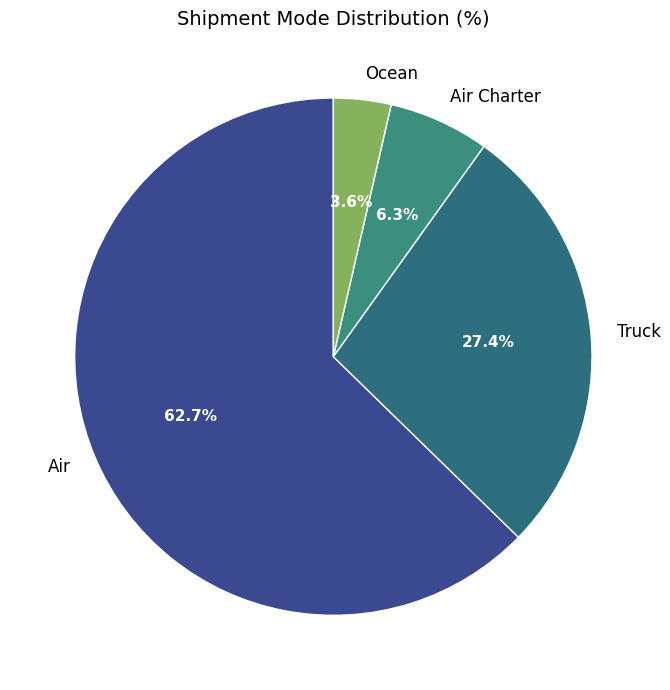


📋 Shipment Mode Analysis:
Shipment Mode  Percentage (%)
          Air            62.7
        Truck            27.4
  Air Charter             6.3
        Ocean             3.6


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Custom colors from your provided boxplot
custom_colors = [
    "#3B4A90",  # Dark blue-purple
    "#2E6F7F",  # Dark teal
    "#3B8F7E",  # Teal green
    "#87B25D"   # Light green
]

# Calculate stats
shipment_mode_stats = df_cleaned['shipment mode'].value_counts()
shipment_mode_percentage = shipment_mode_stats / shipment_mode_stats.sum() * 100

# Create DataFrame for table
shipment_mode_df = pd.DataFrame({
    "Shipment Mode": shipment_mode_percentage.index,
    "Percentage (%)": shipment_mode_percentage.values.round(1)
})

# Plot pie chart
plt.figure(figsize=(7, 7))
wedges, texts, autotexts = plt.pie(
    shipment_mode_percentage,
    labels=shipment_mode_percentage.index,
    autopct='%1.1f%%',
    colors=custom_colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white')
)

# Style labels and percentages
for text in texts:  # Labels
    text.set(size=12, fontweight='normal')
for autotext in autotexts:  # Percentages
    autotext.set(size=11, color='white', fontweight='bold')

plt.title("Shipment Mode Distribution (%)", fontsize=14)
plt.tight_layout()
plt.show()

# Display table
print("\n📋 Shipment Mode Analysis:")
print(shipment_mode_df.to_string(index=False))


## 2. Top 10 Countries By Shipment Demand

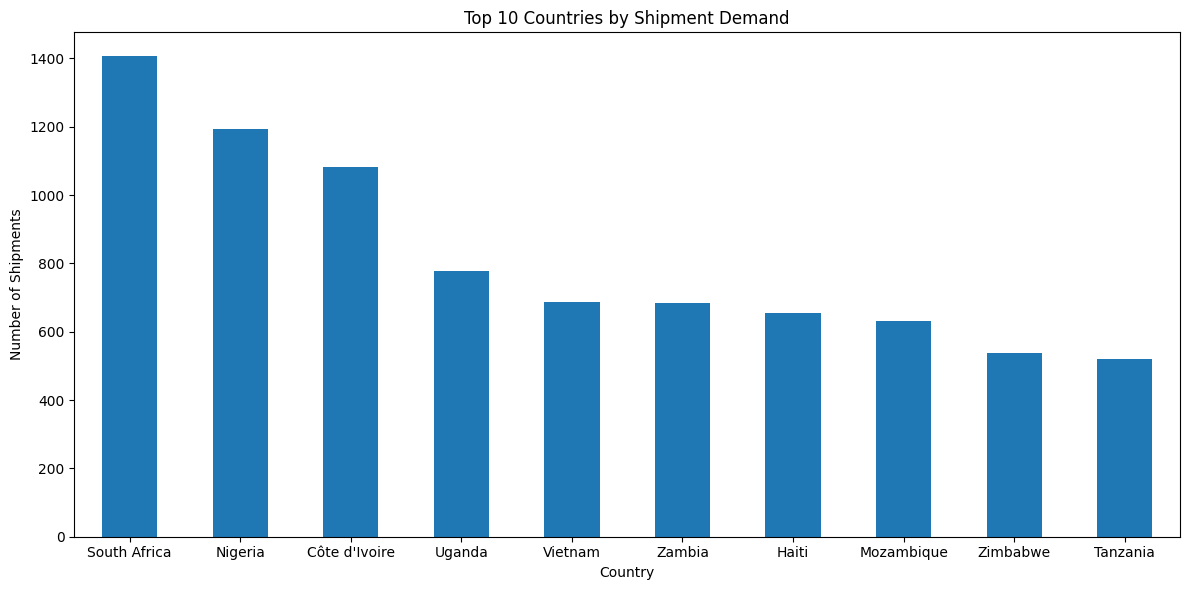

Top 10 Countries by Shipment Demand:
country
South Africa     1406
Nigeria          1194
Côte d'Ivoire    1083
Uganda            779
Vietnam           688
Zambia            683
Haiti             655
Mozambique        631
Zimbabwe          538
Tanzania          519
Name: count, dtype: int64


In [ ]:
# Analyze top 10 countries by shipment demand
plt.figure(figsize=(12, 6))
df_cleaned['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries by Shipment Demand')
plt.xlabel('Country')
plt.ylabel('Number of Shipments')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Display the top 10 countries by shipment demand
top_10_countries = df_cleaned['country'].value_counts().head(10)

print("Top 10 Countries by Shipment Demand:")
print(top_10_countries)

/tmp/ipython-input-710427492.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['delivered to client date'] = pd.to_datetime(df['delivered to client date'], errors='coerce')


Top 5 countries: ['Nigeria', 'Zambia', 'South Africa', 'Mozambique', 'Zimbabwe']
country         Nigeria  Zambia  South Africa  Mozambique  Zimbabwe
delivery_month                                                     
2006-05-01          NaN     NaN           NaN         NaN       NaN
2006-06-01          NaN     NaN           NaN         NaN       NaN
2006-07-01      50500.0     NaN           NaN         NaN       NaN
2006-08-01          NaN   500.0           NaN         NaN       NaN
2006-09-01       1734.0  2250.0           NaN         NaN       NaN


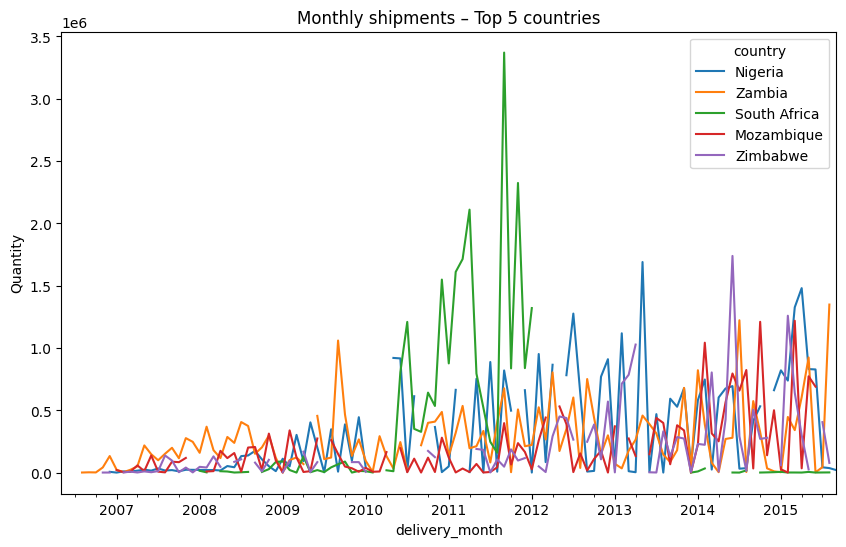

In [ ]:
# ==============================
# 2. LOAD & PREPARE DATA
# ==============================
df = pd.read_csv("Suppy_Chain_Shipment_Data.csv")
df['delivered to client date'] = pd.to_datetime(df['delivered to client date'], errors='coerce')
df.dropna(subset=['delivered to client date'], inplace=True)

# tạo cột month (Period M)
df['delivery_month'] = df['delivered to client date'].dt.to_period('M')

# ==============================
# 2.1 PANEL DATA (country × month)
# ==============================
panel = (
    df.groupby(['delivery_month','country'])['line item quantity']
      .sum()
      .reset_index()
)

# pivot để có ma trận time × country
panel = panel.pivot(index='delivery_month', columns='country', values='line item quantity')
panel.index = pd.to_datetime(panel.index.astype(str))

# chọn top 5 countries theo tổng volume
top5_countries = panel.sum().sort_values(ascending=False).head(5).index
panel_top5 = panel[top5_countries]

print("Top 5 countries:", list(top5_countries))
print(panel_top5.head())

# ==============================
# 2.2 GLOBAL vs. PER-COUNTRY
# ==============================

# --- GLOBAL (panel/global model) ---
# điền NaN = 0 để giữ tất cả countries trong ma trận
panel_global = panel_top5.fillna(0)

# --- PER-COUNTRY (chạy forecast riêng) ---
# ví dụ chọn Nigeria, bỏ các NaN đầu kỳ
nigeria_series = panel_top5['Nigeria'].dropna()

# có thể lặp qua từng country trong top 5
per_country_series = {
    c: panel_top5[c].dropna() for c in top5_countries
}
panel_top5.plot(figsize=(10,6))
plt.title("Monthly shipments – Top 5 countries")
plt.ylabel("Quantity")
plt.show()


## 3. Distribution of Product Groups

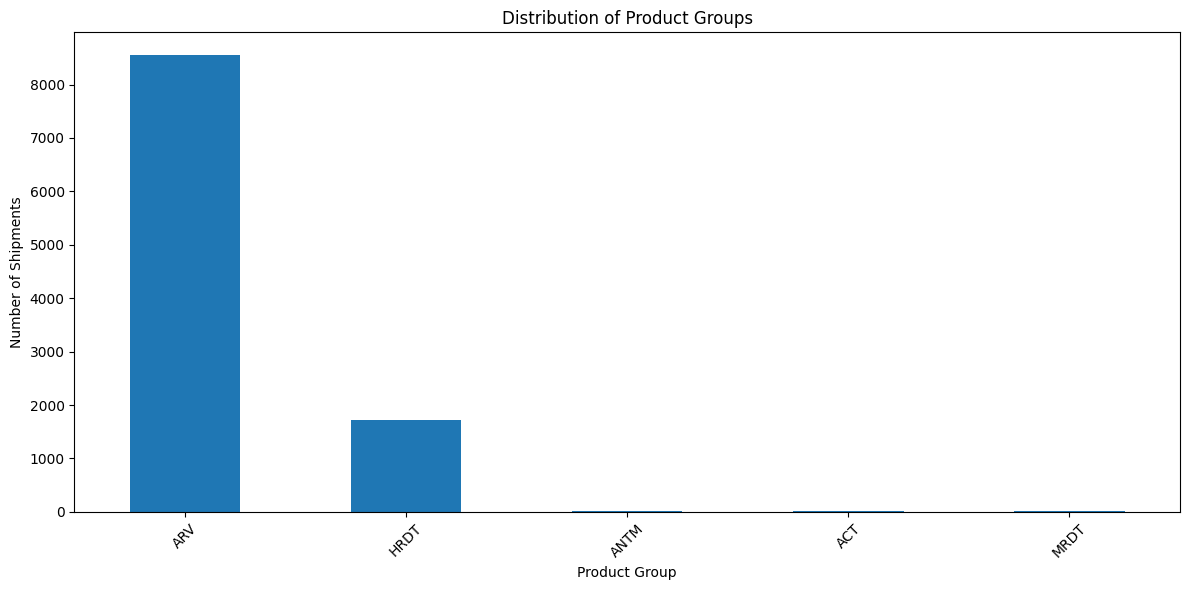

Product Group Analysis:
               Frequency  Percentage
product group                       
ARV                 8550   82.816738
HRDT                1728   16.737699
ANTM                  22    0.213096
ACT                   16    0.154979
MRDT                   8    0.077489


In [ ]:
# Analyze the distribution of product groups
plt.figure(figsize=(12, 6))
df_cleaned['product group'].value_counts().plot(kind='bar')
plt.title('Distribution of Product Groups')
plt.xlabel('Product Group')
plt.ylabel('Number of Shipments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Display the frequency and percentage of each product group
product_group_stats = df_cleaned['product group'].value_counts()
product_group_percentage = df_cleaned['product group'].value_counts(normalize=True) * 100

product_group_analysis = pd.DataFrame({
    'Frequency': product_group_stats,
    'Percentage': product_group_percentage
})

print("Product Group Analysis:")
print(product_group_analysis)

## 4. Relationship between line item quantity vs. line item value

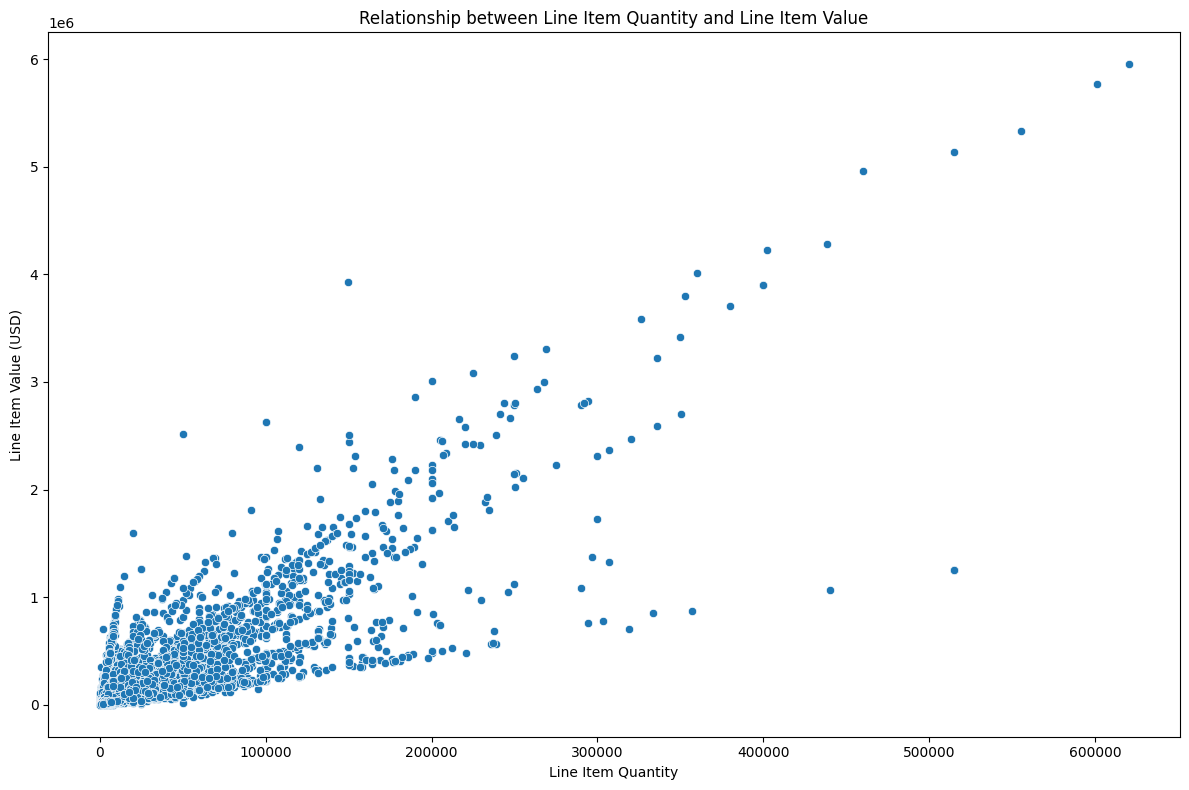

Correlation between Line Item Quantity and Line Item Value: 0.8391
Summary of Line Item Value for top 10 Line Item Quantities:
      line item quantity        mean      median         min         max
5064              619999  5951990.40  5951990.40  5951990.40  5951990.40
5063              600906  5768697.60  5768697.60  5768697.60  5768697.60
5062              555197  5329891.20  5329891.20  5329891.20  5329891.20
5061              515000  1251450.00  1251450.00  1251450.00  1251450.00
5060              514526  5140114.74  5140114.74  5140114.74  5140114.74
5059              460041  4959241.98  4959241.98  4959241.98  4959241.98
5058              440000  1069200.00  1069200.00  1069200.00  1069200.00
5057              438409  4278871.84  4278871.84  4278871.84  4278871.84
5056              401961  4228629.72  4228629.72  4228629.72  4228629.72
5055              400000  3904000.00  3904000.00  3904000.00  3904000.00


In [ ]:
# Scatter plot of line item quantity vs. line item value
plt.figure(figsize=(12, 8))
sns.scatterplot(x='line item quantity', y='line item value', data=df_cleaned)
plt.title('Relationship between Line Item Quantity and Line Item Value')
plt.xlabel('Line Item Quantity')
plt.ylabel('Line Item Value (USD)')
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = df_cleaned['line item quantity'].corr(df_cleaned['line item value'])

print(f"Correlation between Line Item Quantity and Line Item Value: {correlation:.4f}")

# Summary of the relationship
summary = df_cleaned.groupby('line item quantity')['line item value'].agg(['mean', 'median', 'min', 'max']).reset_index()
summary = summary.sort_values('line item quantity', ascending=False).head(10)

print("\
Summary of Line Item Value for top 10 Line Item Quantities:")
print(summary)

# III. Descriptive Analysis

In [ ]:
# Summary statistics of numeric columns
summary_stats = df_cleaned.describe()

# Count of unique values in categorical columns
unique_counts = df_cleaned.select_dtypes(include=['object']).nunique()

# Display the results
print("Summary statistics of numeric columns:")
print(summary_stats)

print("\
Count of unique values in categorical columns:")
print(unique_counts)

Summary statistics of numeric columns:
                 id  unit of measure (per pack)  line item quantity  \
count  10324.000000                10324.000000        10324.000000   
mean   51098.968229                   77.990895        18332.534870   
std    31944.332496                   76.579764        40035.302961   
min        1.000000                    1.000000            1.000000   
25%    12795.750000                   30.000000          408.000000   
50%    57540.500000                   60.000000         3000.000000   
75%    83648.250000                   90.000000        17039.750000   
max    86823.000000                 1000.000000       619999.000000   

       line item value    pack price    unit price  line item insurance (usd)  
count     1.032400e+04  10324.000000  10324.000000               10324.000000  
mean      1.576506e+05     21.910241      0.611701                 234.750202  
std       3.452921e+05     45.609223      3.275808                 494.208887  
m

## 1. Cost Efficiency by shipment modes

Cost analysis by shipment mode:
  shipment mode  line item value  freight cost (usd)  \
1   Air Charter    379034.201769        21052.142642   
2         Ocean    340102.274367        12733.080816   
3         Truck    207555.607456        10176.405000   
0           Air    103144.123783        10271.688375   

   line item insurance (usd)     total_cost  cost_per_dollar  
1                 543.556585  400629.900995         0.056976  
2                 567.808518  353403.163700         0.039108  
3                 294.259442  218026.271898         0.050448  
0                 158.634038  113574.446197         0.101124  


<Figure size 1200x600 with 0 Axes>

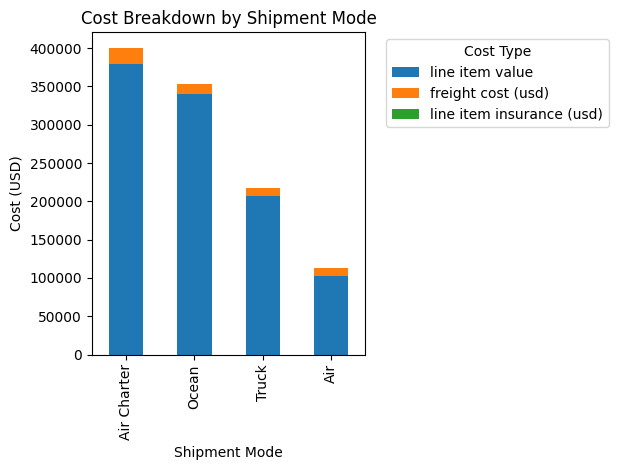

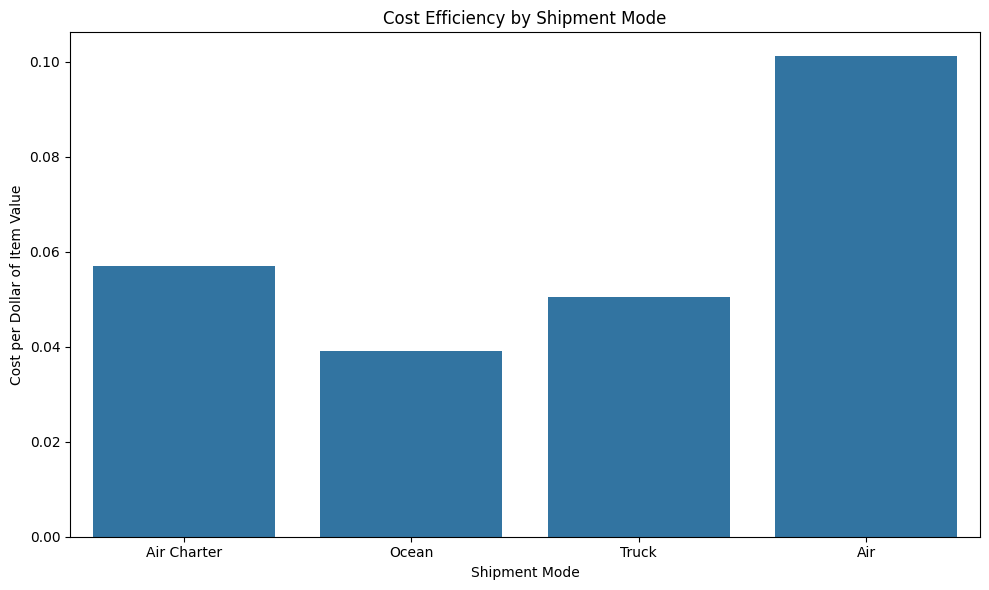

In [ ]:
# Convert columns to numeric, coercing errors to NaN
numeric_columns = ['line item value', 'freight cost (usd)', 'line item insurance (usd)']
for col in numeric_columns:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

# Group by shipment mode and calculate average costs
cost_analysis = df_cleaned.groupby('shipment mode').agg({
    'line item value': 'mean',
    'freight cost (usd)': 'mean',
    'line item insurance (usd)': 'mean'
}).reset_index()

# Calculate total cost
cost_analysis['total_cost'] = cost_analysis['line item value'] + cost_analysis['freight cost (usd)'] + cost_analysis['line item insurance (usd)']

# Calculate cost per dollar of item value
cost_analysis['cost_per_dollar'] = (cost_analysis['freight cost (usd)'] + cost_analysis['line item insurance (usd)']) / cost_analysis['line item value']

# Sort by total cost
cost_analysis = cost_analysis.sort_values('total_cost', ascending=False)

# Display the results
print("Cost analysis by shipment mode:")
print(cost_analysis)

# Visualize the cost breakdown
plt.figure(figsize=(12, 6))
cost_analysis.set_index('shipment mode')[['line item value', 'freight cost (usd)', 'line item insurance (usd)']].plot(kind='bar', stacked=True)
plt.title('Cost Breakdown by Shipment Mode')
plt.xlabel('Shipment Mode')
plt.ylabel('Cost (USD)')
plt.legend(title='Cost Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Visualize the cost efficiency
plt.figure(figsize=(10, 6))
sns.barplot(x='shipment mode', y='cost_per_dollar', data=cost_analysis)
plt.title('Cost Efficiency by Shipment Mode')
plt.xlabel('Shipment Mode')
plt.ylabel('Cost per Dollar of Item Value')
plt.tight_layout()
plt.show()

# IV. Check Seasonality

/tmp/ipython-input-2634126783.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['delivered to client date'] = pd.to_datetime(df['delivered to client date'], errors='coerce')


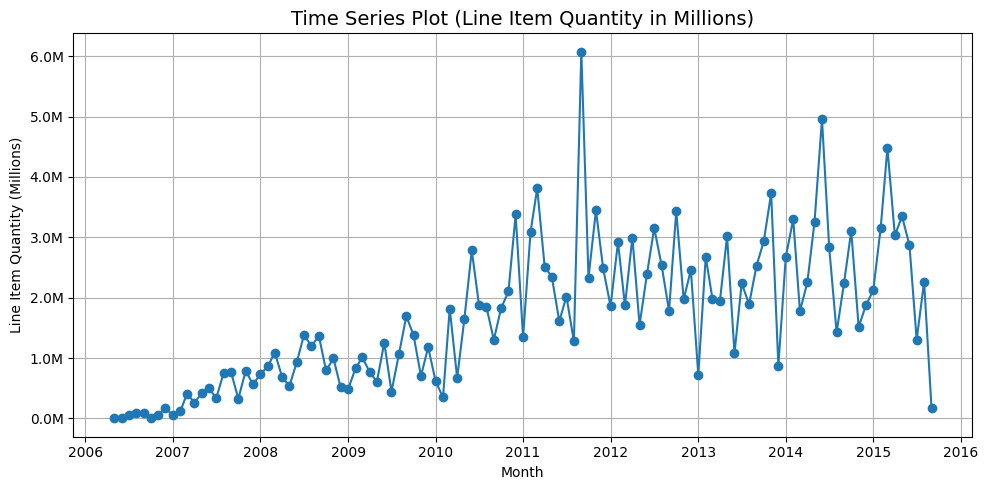

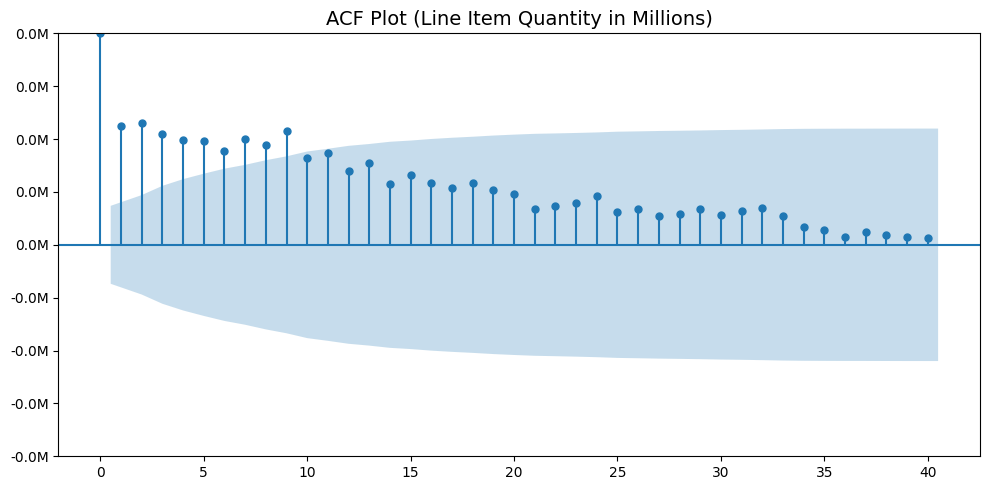

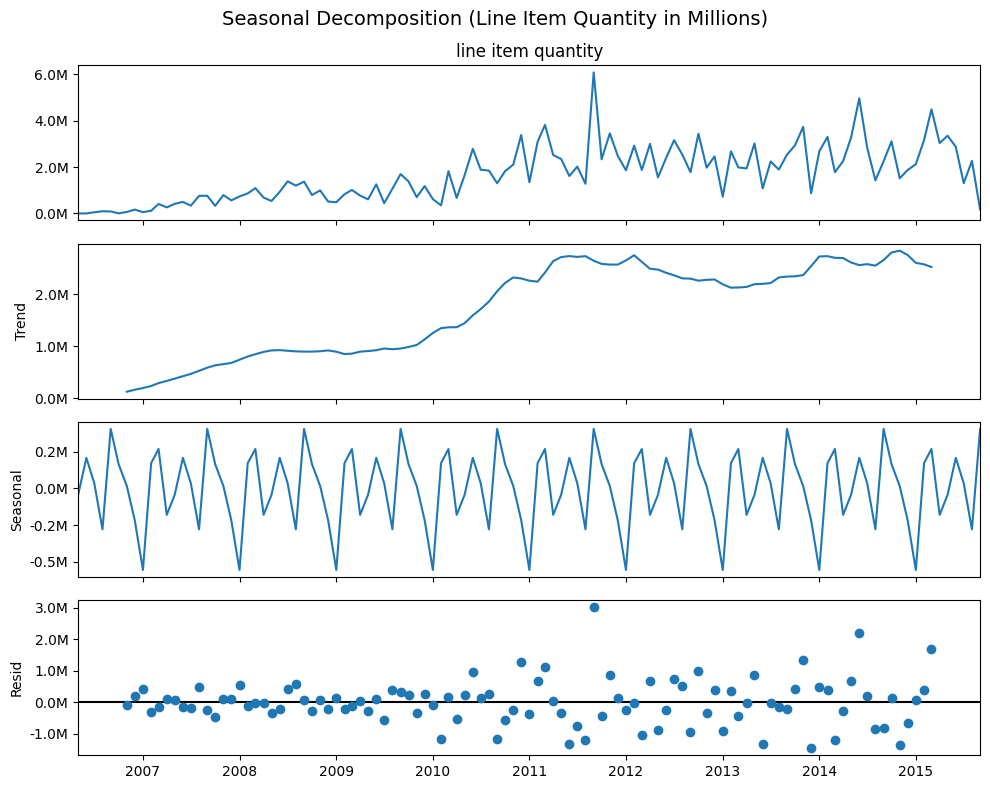


📌 How to interpret the results:
1. Time series plot: Repeating patterns indicate seasonality.
2. ACF plot: Peaks at lags equal to the seasonal period (e.g., 12, 24) suggest seasonality.
3. Seasonal decomposition: A clear, consistent seasonal component confirms seasonality.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib.ticker import FuncFormatter

# === 1. Load and prepare dataset ===
df = pd.read_csv("Suppy_Chain_Shipment_Data.csv")
df['delivered to client date'] = pd.to_datetime(df['delivered to client date'], errors='coerce')
df.dropna(subset=['delivered to client date'], inplace=True)

# === 2. Aggregate to monthly data ===
df['delivery_month'] = df['delivered to client date'].dt.to_period('M')
monthly = (
    df.groupby('delivery_month')['line item quantity']
    .sum()
    .reset_index()
)
monthly['delivery_month'] = pd.to_datetime(monthly['delivery_month'].astype(str))

# Create time series with month as index
ts = monthly.set_index('delivery_month')['line item quantity']

# === Formatter to show millions ===
def millions_formatter(x, pos):
    return f'{x/1_000_000:.1f}M'

# === 3. Plot time series ===
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ts, marker='o')
ax.set_title("Time Series Plot (Line Item Quantity in Millions)", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Line Item Quantity (Millions)")
ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
ax.grid(True)
plt.tight_layout()
plt.show()

# === 4. Plot ACF (Autocorrelation Function) ===
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(ts, lags=40, ax=ax)
ax.set_title("ACF Plot (Line Item Quantity in Millions)", fontsize=14)
ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
plt.tight_layout()
plt.show()

# === 5. Seasonal Decomposition ===
# Assuming monthly data → period=12
decomp = seasonal_decompose(ts, model='additive', period=12)

# Custom seasonal decomposition plot with millions
fig = decomp.plot()
for a in fig.axes:
    a.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
fig.set_size_inches(10, 8)
fig.suptitle("Seasonal Decomposition (Line Item Quantity in Millions)", fontsize=14)
plt.tight_layout()
plt.show()

# === 6. Interpretation guide ===
print("\n📌 How to interpret the results:")
print("1. Time series plot: Repeating patterns indicate seasonality.")
print("2. ACF plot: Peaks at lags equal to the seasonal period (e.g., 12, 24) suggest seasonality.")
print("3. Seasonal decomposition: A clear, consistent seasonal component confirms seasonality.")


# IV. Demand Analysis on selected countries (Nigeria, Zambia, Côte d'Ivoire, South Africa)

In [ ]:
# Define 'df_filtered' by filtering the loaded data for the specified countries
countries_of_interest = ['Nigeria', 'Zambia', 'South Africa', "C\u00f4te d'Ivoire"]
df_filtered = df[df['country'].isin(countries_of_interest)]

# Display the first few rows of df_filtered to verify
print(df_filtered.head())
print("\
Shape of df_filtered:", df_filtered.shape)

   id project code            pq # po / so # asn/dn #        country  \
0   1   100-CI-T01  Pre-PQ Process    SCMS-4    ASN-8  Côte d'Ivoire   
2   4   100-CI-T01  Pre-PQ Process   SCMS-20   ASN-14  Côte d'Ivoire   
5  23   112-NG-T01  Pre-PQ Process   SCMS-87   ASN-57        Nigeria   
6  44   110-ZM-T01  Pre-PQ Process  SCMS-139  ASN-130         Zambia   
8  46   112-NG-T01  Pre-PQ Process  SCMS-156   ASN-93        Nigeria   

  managed by  fulfill via vendor inco term shipment mode  ...  \
0   PMO - US  Direct Drop              EXW           Air  ...   
2   PMO - US  Direct Drop              FCA           Air  ...   
5   PMO - US  Direct Drop              EXW           Air  ...   
6   PMO - US  Direct Drop              DDU           Air  ...   
8   PMO - US  Direct Drop              EXW           Air  ...   

  line item quantity line item value pack price unit price  \
0                 19          551.00      29.00       0.97   
2                500        40000.00      80.00     

In [ ]:
# Analyze Demand
demand_by_country = df_filtered.groupby('country')['line item quantity'].sum().sort_values(ascending=False)

print("Demand by Country:")
print(demand_by_country)

# Analyze Profit Margin
df_filtered['freight cost (usd)'] = pd.to_numeric(df_filtered['freight cost (usd)'], errors='coerce')
df_filtered['line item insurance (usd)'] = pd.to_numeric(df_filtered['line item insurance (usd)'], errors='coerce')
df_filtered['total_cost'] = df_filtered['freight cost (usd)'] + df_filtered['line item insurance (usd)']

value_cost_by_country = df_filtered.groupby('country').agg({
    'line item value': 'sum',
    'total_cost': 'sum'
}).reset_index()

value_cost_by_country['profit_margin'] = (value_cost_by_country['line item value'] - value_cost_by_country['total_cost']) / value_cost_by_country['line item value']

print("\
Profit Margin by Country:")
print(value_cost_by_country.sort_values('profit_margin', ascending=False))

# Score based on demand and profit margin
combined_metrics = pd.merge(demand_by_country.reset_index(), value_cost_by_country, on='country')
combined_metrics['score'] = combined_metrics['line item quantity'] * combined_metrics['profit_margin']

print("\
Combined Metrics (sorted by score):")
print(combined_metrics.sort_values('score', ascending=False))

# Select top 3 locations based on the combined score
top_3_locations = combined_metrics.sort_values('score', ascending=False).head(3)

print("\
Top 3 Recommended Warehouse Locations:")
print(top_3_locations[['country', 'line item quantity', 'profit_margin', 'score']])

Demand by Country:
country
Nigeria          33967950
Zambia           28627539
South Africa     22995781
Côte d'Ivoire    11898572
Name: line item quantity, dtype: int64
Profit Margin by Country:
         country  line item value   total_cost  profit_margin
2   South Africa     1.086701e+08   2660005.86       0.975522
3         Zambia     2.469888e+08   6327611.93       0.974381
1        Nigeria     3.502721e+08  14545113.03       0.958475
0  Côte d'Ivoire     1.208845e+08   6082642.58       0.949682
Combined Metrics (sorted by score):
         country  line item quantity  line item value   total_cost  \
0        Nigeria            33967950     3.502721e+08  14545113.03   
1         Zambia            28627539     2.469888e+08   6327611.93   
2   South Africa            22995781     1.086701e+08   2660005.86   
3  Côte d'Ivoire            11898572     1.208845e+08   6082642.58   

   profit_margin         score  
0       0.958475  3.255742e+07  
1       0.974381  2.789413e+07  
2       

/tmp/ipython-input-1373605929.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['freight cost (usd)'] = pd.to_numeric(df_filtered['freight cost (usd)'], errors='coerce')
/tmp/ipython-input-1373605929.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['line item insurance (usd)'] = pd.to_numeric(df_filtered['line item insurance (usd)'], errors='coerce')
/tmp/ipython-input-1373605929.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
T

/tmp/ipython-input-2984183376.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combined_metrics['country'], y=combined_metrics['line item quantity'], palette='viridis')


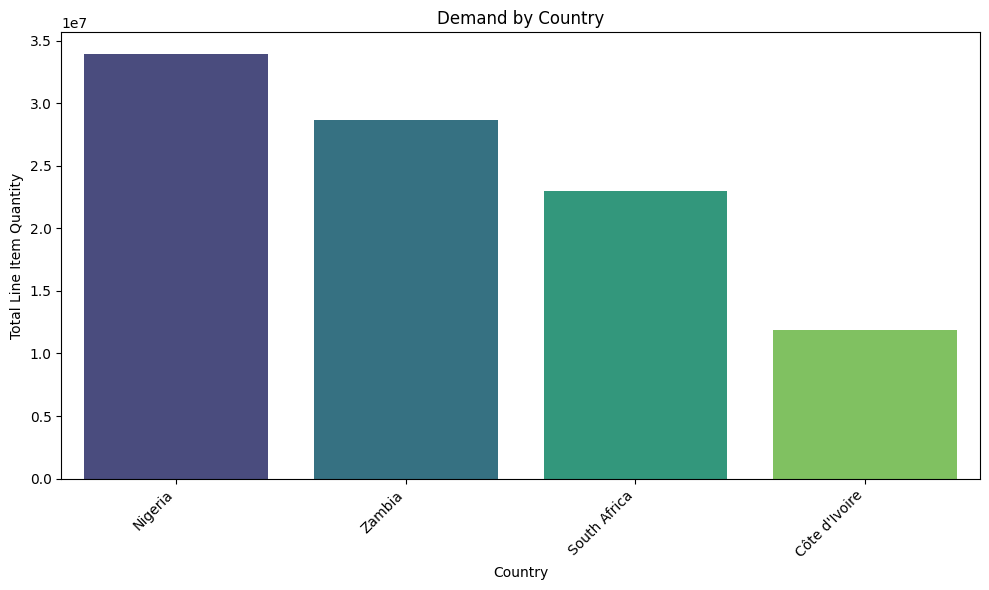

/tmp/ipython-input-2984183376.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combined_metrics['country'], y=combined_metrics['profit_margin'], palette='magma')


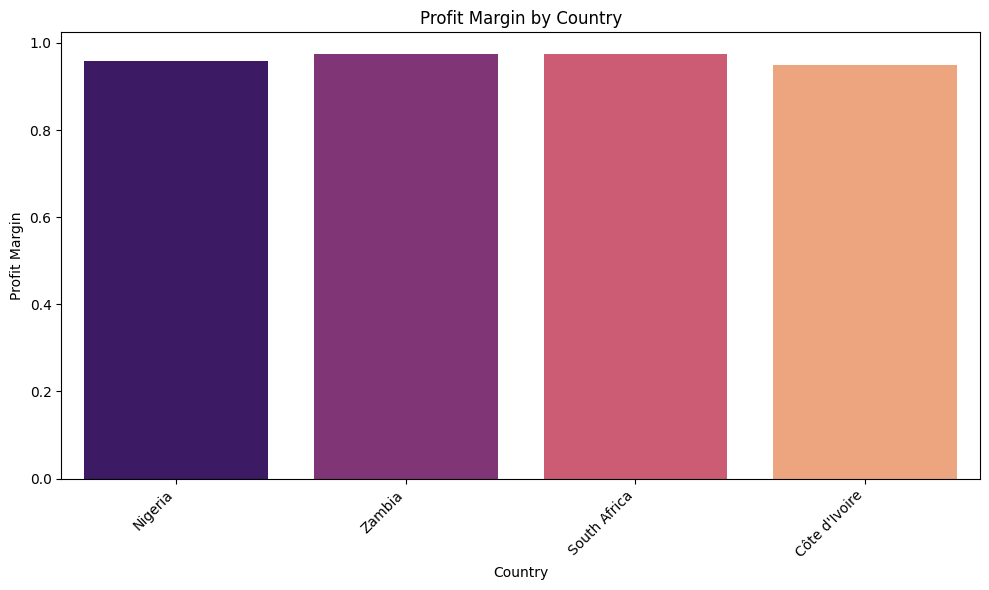

/tmp/ipython-input-2984183376.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combined_metrics['country'], y=combined_metrics['score'], palette='coolwarm')


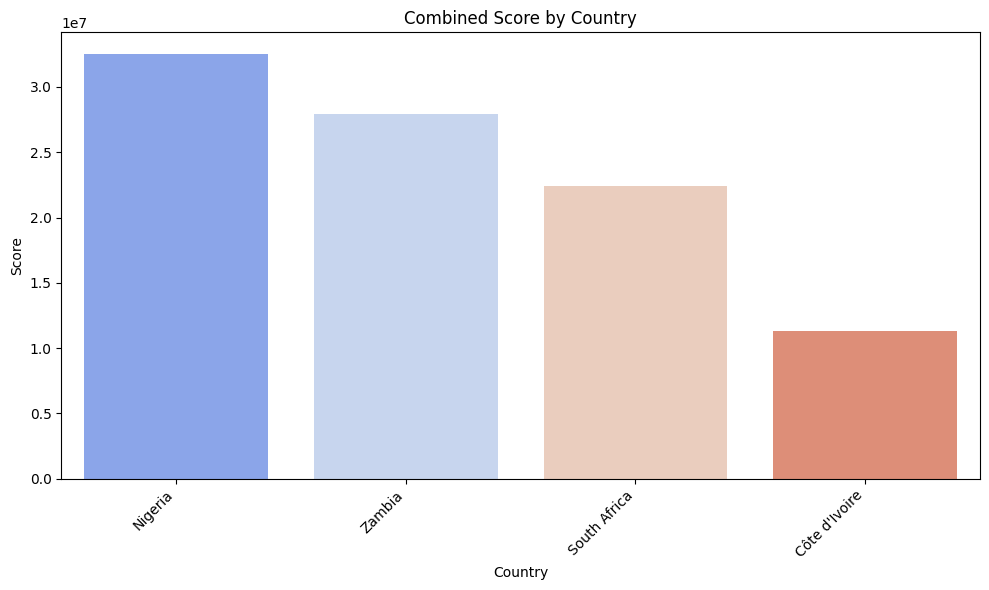

In [ ]:
# Create a barplot for demand by country
plt.figure(figsize=(10, 6))
sns.barplot(x=combined_metrics['country'], y=combined_metrics['line item quantity'], palette='viridis')
plt.title('Demand by Country')
plt.xlabel('Country')
plt.ylabel('Total Line Item Quantity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Create a barplot for profit margin by country
plt.figure(figsize=(10, 6))
sns.barplot(x=combined_metrics['country'], y=combined_metrics['profit_margin'], palette='magma')
plt.title('Profit Margin by Country')
plt.xlabel('Country')
plt.ylabel('Profit Margin')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Create a barplot for combined score by country
plt.figure(figsize=(10, 6))
sns.barplot(x=combined_metrics['country'], y=combined_metrics['score'], palette='coolwarm')
plt.title('Combined Score by Country')
plt.xlabel('Country')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# Calculate the current total freight costs for Nigeria, South Africa, and Côte d'Ivoire
countries_for_warehouses = ['Nigeria', 'South Africa', "Côte d'Ivoire"]
current_freight_costs = df[df['country'].isin(countries_for_warehouses)]['freight cost (usd)'].sum()

# Convert 'freight cost (usd)' to numeric for the relevant countries
df['freight cost (usd)'] = pd.to_numeric(df['freight cost (usd)'], errors='coerce')

# Recalculate the current total freight costs for Nigeria, South Africa, and Côte d'Ivoire
current_freight_costs = df[df['country'].isin(countries_for_warehouses)]['freight cost (usd)'].sum()

# Calculate the reduced freight costs assuming a 30% reduction
reduced_freight_costs = current_freight_costs * 0.7

# Calculate the annual cost savings
annual_cost_savings = current_freight_costs - reduced_freight_costs

print("Current Total Freight Costs: $", round(current_freight_costs, 2))
print("Reduced Total Freight Costs (30% reduction): $", round(reduced_freight_costs, 2))
print("Annual Cost Savings: $", round(annual_cost_savings, 2))

Current Total Freight Costs: $ 22854303.2
Reduced Total Freight Costs (30% reduction): $ 15998012.24
Annual Cost Savings: $ 6856290.96


<Figure size 1200x600 with 0 Axes>

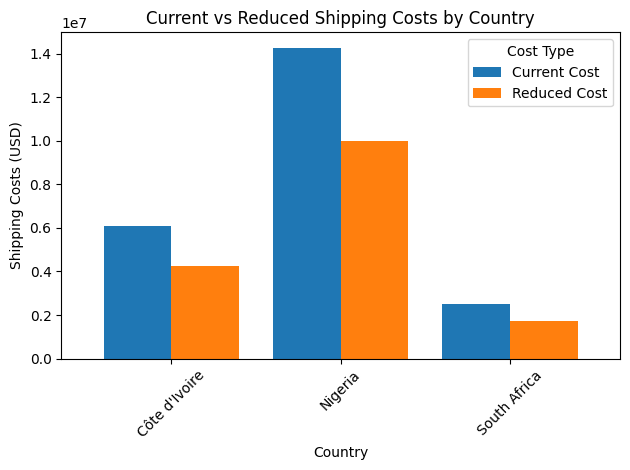

In [ ]:
# Calculate current and reduced costs for each country
countries_for_warehouses = ['Nigeria', 'South Africa', "C\u00f4te d'Ivoire"]
current_costs = df[df['country'].isin(countries_for_warehouses)].groupby('country')['freight cost (usd)'].sum()
reduced_costs = current_costs * 0.7

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'Current Cost': current_costs,
    'Reduced Cost': reduced_costs
})

# Create the bar chart
plt.figure(figsize=(12, 6))
plot_data.plot(kind='bar', width=0.8)
plt.title('Current vs Reduced Shipping Costs by Country')
plt.xlabel('Country')
plt.ylabel('Shipping Costs (USD)')
plt.legend(title='Cost Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# V. Forecating demand

## DATA PREPARATION

/tmp/ipython-input-2327128283.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['delivered to client date'] = pd.to_datetime(df['delivered to client date'], errors='coerce')


Running fold 1/4 (train 23 | test 22)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/tmp/ipython-input-2327128283.py:66: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_snaive = y_snaive.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2327128283.py:137: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_pred_snaive_pos = y_snaive_pos.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2327128283.py:66: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_snaive = y_snaive.fillna(method='bfill').fillna(method='ffill')
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_mode

Running fold 2/4 (train 45 | test 22)


/tmp/ipython-input-2327128283.py:66: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_snaive = y_snaive.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2327128283.py:66: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_snaive = y_snaive.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2327128283.py:66: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_snaive = y_snaive.fillna(method='bfill').fillna(method='ffill')
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/tmp/ipython-input-2327128283.py:66: FutureWarning: Series.fillna with 'method' is 

Running fold 3/4 (train 67 | test 22)


/tmp/ipython-input-2327128283.py:66: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_snaive = y_snaive.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2327128283.py:66: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_snaive = y_snaive.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2327128283.py:66: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_snaive = y_snaive.fillna(method='bfill').fillna(method='ffill')
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Running fold 4/4 (train 89 | test 22)


/tmp/ipython-input-2327128283.py:66: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_snaive = y_snaive.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2327128283.py:137: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_pred_snaive_pos = y_snaive_pos.fillna(method='bfill').fillna(method='ffill')
/tmp/ipython-input-2327128283.py:66: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_snaive = y_snaive.fillna(method='bfill').fillna(method='ffill')
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_mode


Summary (mean ± std) across folds:

                 MAE                   RMSE             WMAPE         MASE  \
                mean        std        mean        std   mean    std  mean   
BaseModel                                                                    
ETS        848226.09  389259.62  1053134.75  497107.81  41.42  10.60  0.91   
LSTM       973540.03  481894.39  1192722.12  598358.09  46.03  13.10  1.00   
RF         695787.49  409226.22   884317.92  547536.65  34.00  14.05  0.74   
SARIMA     833919.60  341596.53  1047578.52  446092.26  40.36   6.54  0.89   
sNaive     947733.88  382941.35  1236509.16  512966.65  45.46   5.46  1.00   

                 
            std  
BaseModel        
ETS        0.17  
LSTM       0.20  
RF         0.24  
SARIMA     0.07  
sNaive     0.00  


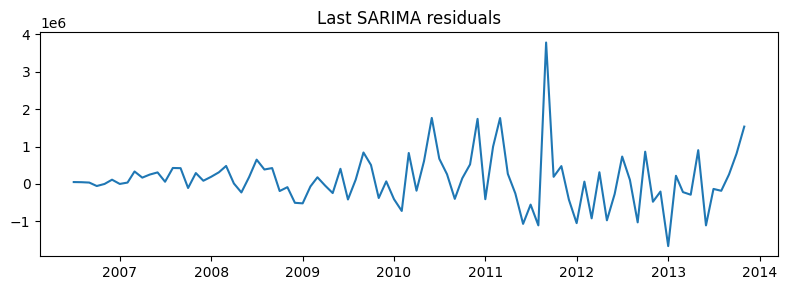

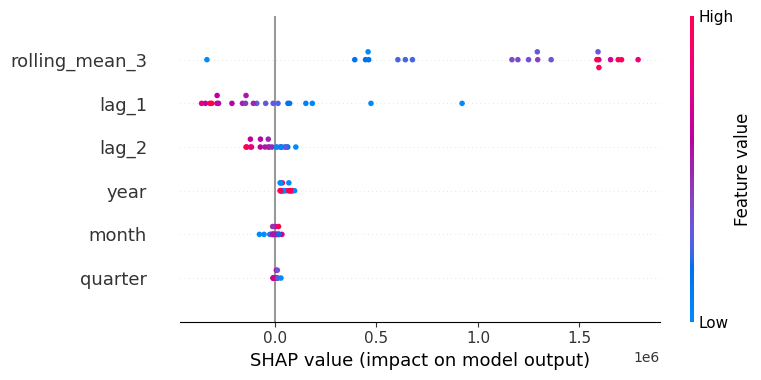

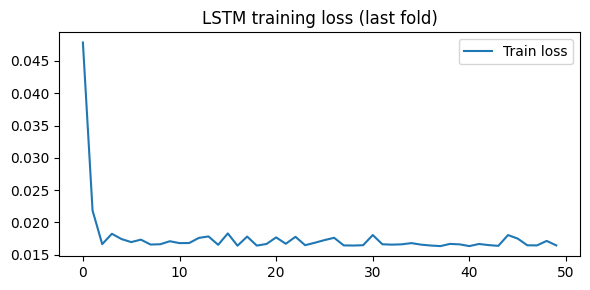

In [ ]:
# ==============================

# 1. LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler

# Optionals (SHAP may be heavy; used in extras)
try:
    import shap
except Exception:
    shap = None

# 2. LOAD & PREPARE DATA
df = pd.read_csv("Suppy_Chain_Shipment_Data.csv")
df['delivered to client date'] = pd.to_datetime(df['delivered to client date'], errors='coerce')
df.dropna(subset=['delivered to client date'], inplace=True)

# aggregate monthly
df['delivery_month'] = df['delivered to client date'].dt.to_period('M')
monthly = df.groupby('delivery_month')['line item quantity'].sum().reset_index()
monthly['delivery_month'] = pd.to_datetime(monthly['delivery_month'].astype(str))

# Create a time-indexed series for SARIMA and baselines
y_series = pd.Series(data=monthly['line item quantity'].values, index=monthly['delivery_month'])

# Features for ML (these use positional alignment with monthly)
monthly = monthly.reset_index(drop=True)  # ensure 0..N-1 index for splits
monthly['month'] = monthly['delivery_month'].dt.month
monthly['quarter'] = monthly['delivery_month'].dt.quarter
monthly['year'] = monthly['delivery_month'].dt.year
monthly['lag_1'] = monthly['line item quantity'].shift(1)
monthly['lag_2'] = monthly['line item quantity'].shift(2)
monthly['rolling_mean_3'] = monthly['line item quantity'].rolling(3).mean()
monthly.dropna(inplace=True)  # drop first rows with NA from lag/rolling

features = ['month','quarter','year','lag_1','lag_2','rolling_mean_3']
X = monthly[features].copy()
y = monthly['line item quantity'].copy().reset_index(drop=True)  # positional series

# Build a corresponding y_series_pos which aligns positions to datetime index
# Find the datetime index slice that corresponds to the remaining monthly rows
# monthly['delivery_month'] currently has dates aligned to rows
y_series_pos = pd.Series(data=monthly['line item quantity'].values, index=monthly['delivery_month'].values)

# 3. METRICS FUNCTION (robust: works with arrays/Series of different types)
def compute_metrics(y_true, y_pred, y_snaive):
    y_true = pd.Series(y_true).reset_index(drop=True).astype(float)
    y_pred = pd.Series(y_pred).reset_index(drop=True).astype(float)
    # y_snaive may be Series with datetime index or positional; convert and align length
    y_snaive = pd.Series(y_snaive).reset_index(drop=True).astype(float)

    # if seasonal naive is all NaN (too short), fallback to mean of y_true
    if y_snaive.isna().all():
        y_snaive = pd.Series([y_true.mean()] * len(y_true))
    else:
        # fill remaining NaNs
        y_snaive = y_snaive.fillna(method='bfill').fillna(method='ffill')
        if len(y_snaive) != len(y_true):
            y_snaive = pd.Series(y_snaive.values[:len(y_true)])
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wmape = (np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))) * 100 if np.sum(np.abs(y_true)) != 0 else np.nan
    denom = mean_absolute_error(y_true, y_snaive) if len(y_snaive)>0 else np.nan
    mase = mae / denom if denom and denom != 0 else np.nan
    return mae, rmse, wmape, mase

# 4. ROLLING BACKTEST
n_splits = 4
tscv = TimeSeriesSplit(n_splits=n_splits)
results = {'Model':[], 'MAE':[], 'RMSE':[], 'WMAPE':[], 'MASE':[]}

# For tracking last trained models for diagnostics (optional)
last_sarima = None
last_rf = None
last_lstm_history = None
last_X_test = None
last_y_test = None

# season parameter
season = 12

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"Running fold {fold+1}/{n_splits} (train {len(train_idx)} | test {len(test_idx)})")
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train_pos, y_test_pos = y.iloc[train_idx], y.iloc[test_idx]  # positional series (arrays)
    # obtain datetime-indexed train/test for SARIMA/baselines using y_series_pos
    idx_train_dates = y_series_pos.index[train_idx]
    idx_test_dates = y_series_pos.index[test_idx]
    y_train_series = y_series_pos.loc[idx_train_dates]
    y_test_series = y_series_pos.loc[idx_test_dates]

    # Seasonal naive baseline for the test period (use full series shift to get seasonal values)
    # y_shifted aligns with the same index as y_series_pos
    y_shifted = y_series_pos.shift(season)
    # select test positions by index
    y_snaive_candidate = y_shifted.loc[idx_test_dates] if set(idx_test_dates).issubset(set(y_shifted.index)) else pd.Series([np.nan]*len(idx_test_dates))
    # convert to positional series for compute_metrics
    y_snaive_pos = pd.Series(y_snaive_candidate.values)

    # ==== ETS (Holt-Winters) with safe initialization/fallback ====
    try:
        if len(y_train_series) >= 24:
            ets_model = ExponentialSmoothing(
                y_train_series,
                seasonal='add',
                seasonal_periods=season,
                initialization_method="estimated"
            ).fit(optimized=True)
        else:
            # fallback to SimpleExpSmoothing if too short
            ets_model = SimpleExpSmoothing(y_train_series, initialization_method="estimated").fit(optimized=True)
        y_pred_ets_series = ets_model.forecast(len(y_test_series))
        y_pred_ets_pos = pd.Series(y_pred_ets_series.values)
    except Exception as e:
        print("ETS failed on fold", fold+1, "-> fallback to sNaive prediction. Error:", e)
        y_pred_ets_pos = y_snaive_pos.copy()

    mae, rmse, wmape, mase = compute_metrics(y_test_pos.values, y_pred_ets_pos.values, y_snaive_pos.values)
    results['Model'].append(f'ETS_fold{fold+1}')
    results['MAE'].append(mae); results['RMSE'].append(rmse)
    results['WMAPE'].append(wmape); results['MASE'].append(mase)

    # ==== sNaive baseline (explicit append as a model) ====
    # If seasonal naive candidate is all NaN (not enough history), fallback to repeating last value
    if pd.Series(y_snaive_pos).isna().all():
        y_pred_snaive_pos = pd.Series([y_train_pos.mean()] * len(y_test_pos))
    else:
        y_pred_snaive_pos = y_snaive_pos.fillna(method='bfill').fillna(method='ffill')
    mae, rmse, wmape, mase = compute_metrics(y_test_pos.values, y_pred_snaive_pos.values, y_snaive_pos.values)
    results['Model'].append(f'sNaive_fold{fold+1}')
    results['MAE'].append(mae); results['RMSE'].append(rmse)
    results['WMAPE'].append(wmape); results['MASE'].append(mase)

    # ==== SARIMA ====
    try:
        # SARIMA expects a datetime-indexed series
        sarima_model = SARIMAX(y_train_series,
                               order=(1,1,1),
                               seasonal_order=(0,1,1,season),
                               enforce_stationarity=False,
                               enforce_invertibility=False).fit(disp=False)
        y_pred_sarima_series = sarima_model.forecast(len(y_test_series))
        y_pred_sarima_pos = pd.Series(y_pred_sarima_series.values)
        last_sarima = sarima_model
    except Exception as e:
        print("SARIMA failed on fold", fold+1, "-> fallback to ETS or sNaive. Error:", e)
        # fallback: use ETS prediction if available else sNaive
        if 'y_pred_ets_pos' in locals() and len(y_pred_ets_pos)==len(y_test_pos):
            y_pred_sarima_pos = y_pred_ets_pos.copy()
        else:
            y_pred_sarima_pos = y_pred_snaive_pos.copy()

    mae, rmse, wmape, mase = compute_metrics(y_test_pos.values, y_pred_sarima_pos.values, y_snaive_pos.values)
    results['Model'].append(f'SARIMA_fold{fold+1}')
    results['MAE'].append(mae); results['RMSE'].append(rmse)
    results['WMAPE'].append(wmape); results['MASE'].append(mase)

    # ==== Random Forest ====
    rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
    rf.fit(X_train, y_train_pos)
    y_pred_rf = rf.predict(X_test)
    last_rf = rf
    mae, rmse, wmape, mase = compute_metrics(y_test_pos.values, y_pred_rf, y_snaive_pos.values)
    results['Model'].append(f'RF_fold{fold+1}')
    results['MAE'].append(mae); results['RMSE'].append(rmse)
    results['WMAPE'].append(wmape); results['MASE'].append(mase)

    # ==== LSTM (simple iterative forecast) ====
    # Prepare scaled series using y_train_pos only
    scaler = MinMaxScaler()
    ts_train_scaled = scaler.fit_transform(y_train_pos.values.reshape(-1,1))

    look_back = 12  # window
    X_lstm_seq, y_lstm_seq = [], []
    for i in range(len(ts_train_scaled) - look_back):
        X_lstm_seq.append(ts_train_scaled[i:i+look_back])
        y_lstm_seq.append(ts_train_scaled[i+look_back])
    if len(X_lstm_seq) < 1:
        # not enough data to train LSTM -> fallback to sNaive
        y_pred_lstm = y_pred_snaive_pos.copy()
    else:
        X_lstm_seq = np.array(X_lstm_seq)
        y_lstm_seq = np.array(y_lstm_seq)
        model = models.Sequential([
            layers.Input(shape=(look_back,1)),
            layers.LSTM(64, return_sequences=True),
            layers.LSTM(32),
            layers.Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')
        history = model.fit(X_lstm_seq, y_lstm_seq, epochs=50, batch_size=8, verbose=0)
        last_lstm_history = history

        # iterative forecasting for len(y_test_pos) steps
        last_input = ts_train_scaled[-look_back:].reshape(1,look_back,1)
        preds_scaled = []
        for _ in range(len(y_test_pos)):
            p = model.predict(last_input, verbose=0)
            preds_scaled.append(p[0,0])
            # roll
            last_input = np.roll(last_input, -1, axis=1)
            last_input[0, -1, 0] = p[0,0]
        y_pred_lstm = scaler.inverse_transform(np.array(preds_scaled).reshape(-1,1)).flatten()

    mae, rmse, wmape, mase = compute_metrics(y_test_pos.values, y_pred_lstm, y_snaive_pos.values)
    results['Model'].append(f'LSTM_fold{fold+1}')
    results['MAE'].append(mae); results['RMSE'].append(rmse)
    results['WMAPE'].append(wmape); results['MASE'].append(mase)

    # save last test set for diagnostics
    last_X_test = X_test.copy()
    last_y_test = y_test_pos.copy()

# 5. SUMMARY RESULTS
results_df = pd.DataFrame(results)
results_df['BaseModel'] = results_df['Model'].str.split('_').str[0]
summary = results_df.groupby('BaseModel')[['MAE','RMSE','WMAPE','MASE']].agg(['mean','std']).round(2)
print("\nSummary (mean ± std) across folds:\n")
print(summary)

# 6. EXTRAS / DIAGNOSTICS
# 6.1 SARIMA residuals (if available)
if 'last_sarima' in locals() and last_sarima is not None:
    try:
        res = last_sarima.resid
        plt.figure(figsize=(8,3))
        plt.plot(res); plt.title("Last SARIMA residuals"); plt.tight_layout(); plt.show()
    except Exception as e:
        print("Could not plot SARIMA residuals:", e)

# 6.2 RF SHAP (if shap available)
if shap is not None and last_rf is not None and last_X_test is not None:
    try:
        explainer = shap.TreeExplainer(last_rf)
        shap_values = explainer.shap_values(last_X_test)
        shap.summary_plot(shap_values, last_X_test)
    except Exception as e:
        print("SHAP plotting failed:", e)
else:
    print("SHAP not available or RF/test set missing; skipping SHAP plots.")

# 6.3 LSTM loss curve (if history available)
if last_lstm_history is not None:
    plt.figure(figsize=(6,3))
    plt.plot(last_lstm_history.history['loss'], label='Train loss')
    plt.title("LSTM training loss (last fold)"); plt.legend(); plt.tight_layout(); plt.show()


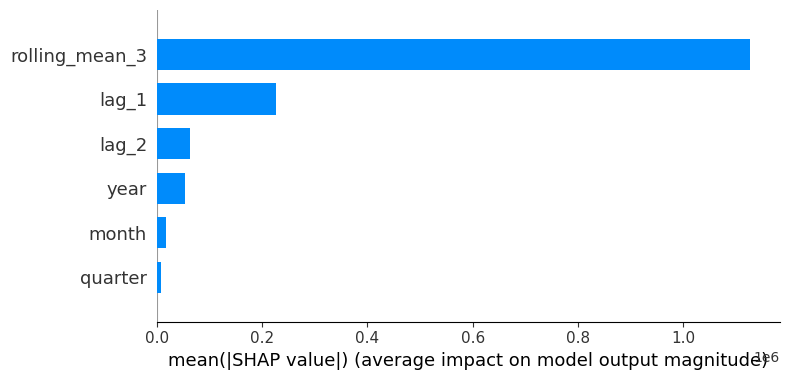

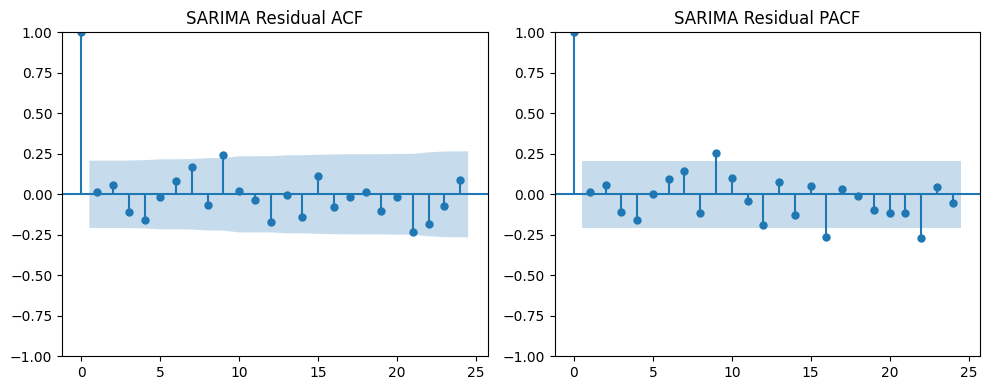


🔍 SARIMA Ljung-Box test (lag=12):
      lb_stat  lb_pvalue
12  17.062783   0.147251


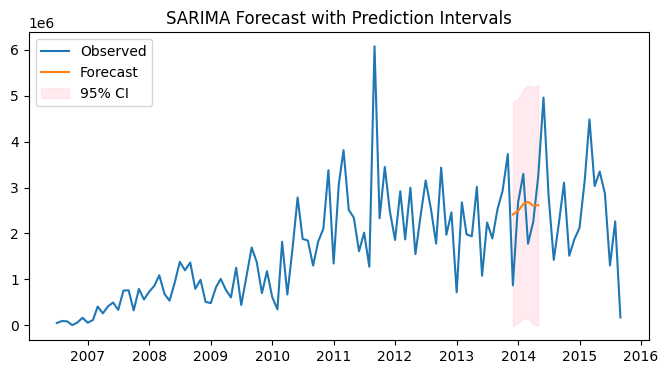

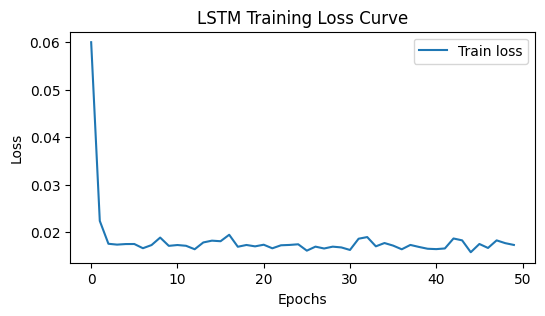


📉 RF Ablation (without rolling_mean_3) - MAE: 238144.29


In [ ]:
# =====================================================
# MODEL DIAGNOSTICS & INTERPRETABILITY
# =====================================================

import matplotlib.pyplot as plt
import statsmodels.api as sm

# --- 1. Random Forest: Feature Importance (via SHAP or permutation importance) ---
try:
    import shap
    explainer = shap.TreeExplainer(last_rf)
    shap_values = explainer.shap_values(last_X_test)
    shap.summary_plot(shap_values, last_X_test, plot_type="bar")
except Exception as e:
    print("SHAP not available, falling back to sklearn feature importance:", e)
    importances = last_rf.feature_importances_
    plt.barh(last_X_test.columns, importances)
    plt.title("RF Feature Importances")
    plt.show()

# --- 2. SARIMA: Residual Diagnostics ---
if last_sarima is not None:
    res = last_sarima.resid

    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    sm.graphics.tsa.plot_acf(res, lags=24, ax=axes[0])
    sm.graphics.tsa.plot_pacf(res, lags=24, ax=axes[1])
    axes[0].set_title("SARIMA Residual ACF")
    axes[1].set_title("SARIMA Residual PACF")
    plt.tight_layout()
    plt.show()

    # Ljung-Box test
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb_test = acorr_ljungbox(res, lags=[12], return_df=True)
    print("\n🔍 SARIMA Ljung-Box test (lag=12):")
    print(lb_test)

    # Forecast with prediction intervals
    sarima_forecast = last_sarima.get_forecast(steps=6)
    forecast_mean = sarima_forecast.predicted_mean
    forecast_ci = sarima_forecast.conf_int()

    plt.figure(figsize=(8,4))
    plt.plot(y_series_pos, label="Observed")
    plt.plot(forecast_mean.index, forecast_mean, label="Forecast")
    plt.fill_between(forecast_ci.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1],
                     color='pink', alpha=0.3, label="95% CI")
    plt.title("SARIMA Forecast with Prediction Intervals")
    plt.legend()
    plt.show()

# --- 3. LSTM: Training Stability ---
if last_lstm_history is not None:
    plt.figure(figsize=(6,3))
    plt.plot(last_lstm_history.history['loss'], label="Train loss")
    plt.title("LSTM Training Loss Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

# --- 4. LSTM: Simple Ablation (remove rolling_mean_3 feature and re-train RF as benchmark) ---
# Example: compare RF with and without rolling_mean_3
features_ablation = ['month','quarter','year','lag_1','lag_2']  # dropped rolling_mean_3
X_ablation = monthly[features_ablation]
y_ablation = monthly['line item quantity']

rf_ablation = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_ablation.fit(X_ablation, y_ablation)
y_pred_ablation = rf_ablation.predict(X_ablation)

mae_ablation = mean_absolute_error(y_ablation, y_pred_ablation)
print(f"\n📉 RF Ablation (without rolling_mean_3) - MAE: {mae_ablation:.2f}")


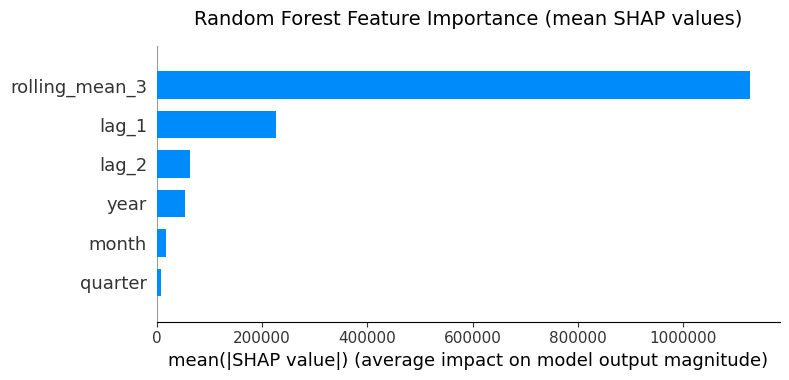

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap

# Tạo explainer và SHAP values
explainer = shap.TreeExplainer(last_rf)
shap_values = explainer.shap_values(last_X_test)

# --- Bar plot ---
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, last_X_test, plot_type="bar", show=False)

ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=False))
ax.ticklabel_format(style='plain', axis='x')  # ép hiển thị số thường
plt.title("Random Forest Feature Importance (mean SHAP values)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


In [ ]:
#!pip install arch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.3/978.3 kB 9.3 MB/s eta 0:00:00


## TRADITIONAL : Sarima

## Sarima

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import plotly.graph_objs as go

# === SARIMA MODEL BLOCK ===

# 1. Set index
ts = monthly.set_index('delivery_month')['line item quantity']

# 2. Train/Test split
train_size = int(len(ts) * 0.8)
train, test = ts.iloc[:train_size], ts.iloc[train_size:]

# 3. Build & fit SARIMA (Best params: (1,1,1), (0,1,1,12))
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)

# 4. Predict on test set
y_pred_test = sarima_fit.get_forecast(steps=len(test)).predicted_mean

mae = mean_absolute_error(test, y_pred_test)
rmse = np.sqrt(mean_squared_error(test, y_pred_test))
wmape = np.sum(np.abs(test - y_pred_test)) / np.sum(np.abs(test)) * 100

print("\n📊 SARIMA Evaluation (TEST set):")
print(f" MAE   : {mae:.2f}")
print(f" RMSE  : {rmse:.2f}")
print(f" WMAPE : {wmape:.2f}%")

# 5. Forecast next 6 months
future_steps = len(test) + 6
forecast_values = sarima_fit.get_forecast(steps=future_steps).predicted_mean[-6:]
future_months = pd.date_range(start=ts.index[-1] + pd.DateOffset(months=1), periods=6, freq='MS')

forecast_df = pd.DataFrame({
    'Month': future_months,
    'Forecast Quantity': forecast_values.round(2).values
})
print("\n📋 SARIMA Forecast for next 6 months:")
print(forecast_df.to_string(index=False))

# 6. Interactive plot
fig = go.Figure()
fig.add_trace(go.Scatter(x=train.index, y=train, mode='lines+markers',
                         name='Train Actual', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=test.index, y=test, mode='lines+markers',
                         name='Test Actual', line=dict(color='green')))
fig.add_trace(go.Scatter(x=test.index, y=y_pred_test, mode='lines+markers',
                         name='Test Predicted', line=dict(color='orange', dash='dash')))
fig.add_trace(go.Scatter(x=future_months, y=forecast_values, mode='lines+markers',
                         name='Forecast (Next 6 months)', line=dict(color='red', dash='dot')))

fig.update_layout(title='📊 SARIMA Forecast (Best Params)',
                  xaxis_title='Month',
                  yaxis_title='Line Item Quantity',
                  template='plotly_white',
                  hovermode='x unified',
                  height=500)
fig.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



📊 SARIMA Evaluation (TEST set):
 MAE   : 923514.08
 RMSE  : 1146964.46
 WMAPE : 36.28%

📋 SARIMA Forecast for next 6 months:
     Month  Forecast Quantity
2015-10-01         2553761.90
2015-11-01         2516796.69
2015-12-01         2550949.48
2016-01-01         2354250.26
2016-02-01         2554023.45
2016-03-01         2588387.36


🔹 Box-Cox lambda: 0.512

📊 ADF Test before differencing:
   ADF Statistic : -2.718
   p-value       : 0.071


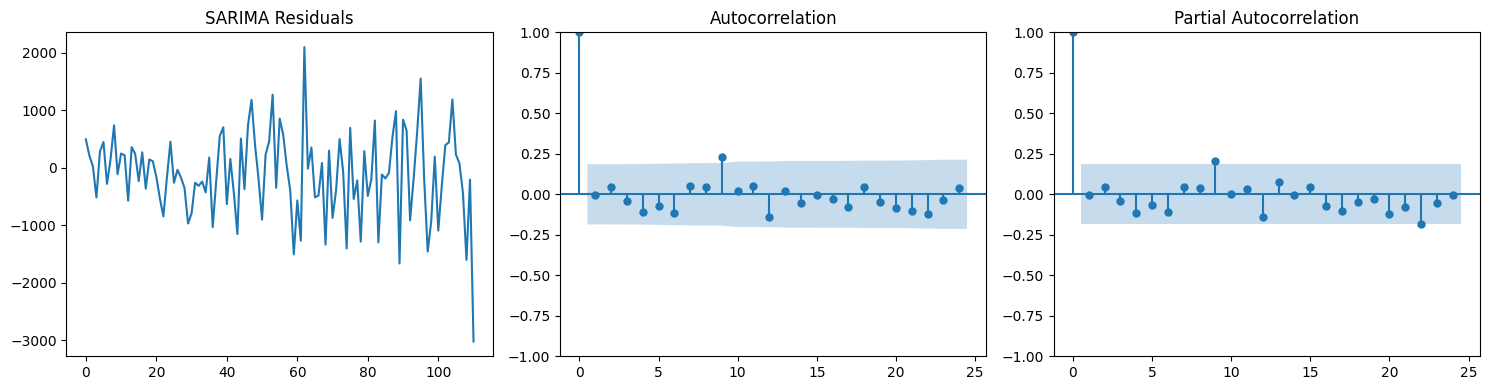


📊 Ljung–Box Test (lag=12):
      lb_stat  lb_pvalue
12  13.877298   0.308612


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import boxcox

# === EXTRA BLOCK: Stationarity & Diagnostics for SARIMA ===

# 1. Box-Cox transformation (variance stabilization)
ts_values = ts.values
ts_positive = ts_values + 1e-6  # tránh giá trị 0
ts_boxcox, lam = boxcox(ts_positive)
print(f"🔹 Box-Cox lambda: {lam:.3f}")

# ADF test before differencing
adf_result = adfuller(ts_boxcox)
print("\n📊 ADF Test before differencing:")
print(f"   ADF Statistic : {adf_result[0]:.3f}")
print(f"   p-value       : {adf_result[1]:.3f}")

# 2. Fit SARIMA again (using same params but Box-Cox data)
sarima_model = sm.tsa.statespace.SARIMAX(
    ts_boxcox,
    order=(1, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)

# 3. Residual diagnostics
residuals = sarima_fit.resid

# Plot residuals, ACF, PACF
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(residuals)
axes[0].set_title("SARIMA Residuals")

sm.graphics.tsa.plot_acf(residuals, lags=24, ax=axes[1])
sm.graphics.tsa.plot_pacf(residuals, lags=24, ax=axes[2])
plt.tight_layout()
plt.show()

# 4. Ljung–Box test (white noise check)
lb_test = acorr_ljungbox(residuals, lags=[12], return_df=True)
print("\n📊 Ljung–Box Test (lag=12):")
print(lb_test)


# MACHINE LEARNING: Random Forest

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import plotly.graph_objs as go

# 1. Load and preprocess data
df = pd.read_csv("Suppy_Chain_Shipment_Data.csv")
df['delivered to client date'] = pd.to_datetime(df['delivered to client date'], errors='coerce')
df.dropna(subset=['delivered to client date'], inplace=True)

df['delivery_month'] = df['delivered to client date'].dt.to_period('M')
monthly = df.groupby('delivery_month')['line item quantity'].sum().reset_index()
monthly['delivery_month'] = pd.to_datetime(monthly['delivery_month'].astype(str))

# 2. Feature engineering
monthly['month'] = monthly['delivery_month'].dt.month
monthly['quarter'] = monthly['delivery_month'].dt.quarter
monthly['year'] = monthly['delivery_month'].dt.year
monthly['lag_1'] = monthly['line item quantity'].shift(1)
monthly['lag_2'] = monthly['line item quantity'].shift(2)
monthly['rolling_mean_3'] = monthly['line item quantity'].rolling(3).mean()
monthly.dropna(inplace=True)
monthly.reset_index(drop=True, inplace=True)

features = ['month', 'quarter', 'year', 'lag_1', 'lag_2', 'rolling_mean_3']
X = monthly[features]
y = monthly['line item quantity']

# 3. Train/test split
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
months_train = monthly['delivery_month'].iloc[:train_size]
months_test = monthly['delivery_month'].iloc[train_size:]

# 4. GridSearchCV for RF hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
tscv = TimeSeriesSplit(n_splits=5)
rf_base = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf_base, param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)
rf = grid_search.best_estimator_

# 5. Evaluate on test set
y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
wmape = np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test)) * 100

print("📊 Model Evaluation Metrics (Improved RF on TEST set):")
print(f"   MAE   : {mae:.2f}")
print(f"   RMSE  : {rmse:.2f}")
print(f"   WMAPE : {wmape:.2f}%")

# 6. Forecast next 6 months
forecast_df = monthly.copy()
future_preds = []

for i in range(6):
    last_row = forecast_df.iloc[-1]
    next_month = last_row['delivery_month'] + pd.DateOffset(months=1)
    new_row = {
        'delivery_month': next_month,
        'month': next_month.month,
        'quarter': (next_month.month - 1) // 3 + 1,
        'year': next_month.year,
        'lag_1': forecast_df.iloc[-1]['line item quantity'],
        'lag_2': forecast_df.iloc[-2]['line item quantity'],
        'rolling_mean_3': forecast_df['line item quantity'].iloc[-3:].mean()
    }
    pred = rf.predict(pd.DataFrame([new_row])[features])[0]
    new_row['line item quantity'] = pred
    forecast_df = pd.concat([forecast_df, pd.DataFrame([new_row])], ignore_index=True)
    future_preds.append((next_month, pred))

# 7. Visualization: Train, Test, Forecast
fig = go.Figure()

fig.add_trace(go.Scatter(x=months_train, y=y_train, mode='lines+markers', name='Train Actual', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=months_test, y=y_test, mode='lines+markers', name='Test Actual', line=dict(color='green')))
fig.add_trace(go.Scatter(x=months_test, y=y_pred, mode='lines+markers', name='Test Predicted', line=dict(color='orange', dash='dash')))
fig.add_trace(go.Scatter(x=[x[0] for x in future_preds], y=[x[1] for x in future_preds],
                         name='Forecast (Future 6 months)', mode='lines+markers', line=dict(color='red', dash='dot')))

fig.update_layout(title='📈 Improved Random Forest: Train, Test, and Future Forecast',
                  xaxis_title='Month', yaxis_title='Line Item Quantity',
                  template='plotly_white', hovermode='x unified', height=500)
fig.show()

# 8. Forecast table
result_df = pd.DataFrame(future_preds, columns=['Month', 'Forecast Quantity'])
print("\n📋 Forecast for next 6 months:")
print(result_df.to_string(index=False))


/tmp/ipython-input-2827370669.py:10: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



📊 Model Evaluation Metrics (Improved RF on TEST set):
   MAE   : 683541.72
   RMSE  : 868430.18
   WMAPE : 26.85%



📋 Forecast for next 6 months:
     Month  Forecast Quantity
2015-10-01       1.410867e+06
2015-11-01       1.216914e+06
2015-12-01       1.071764e+06
2016-01-01       1.302215e+06
2016-02-01       1.168396e+06
2016-03-01       1.226045e+06


## DEEP LEARNING: LSTM

---



In [ ]:
#!pip install optuna

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import plotly.graph_objs as go
import pandas as pd

# Turn off scientific notation
np.set_printoptions(suppress=True)

# 1. Normalize the time series
ts = monthly['line item quantity'].values.reshape(-1, 1)
scaler = MinMaxScaler()
ts_scaled = scaler.fit_transform(ts)

# 2. Create supervised dataset
look_back = 36
forecast_horizon = 6
X, y = [], []
for i in range(look_back, len(ts_scaled) - forecast_horizon + 1):
    X.append(ts_scaled[i - look_back:i])
    y.append(ts_scaled[i:i + forecast_horizon].flatten())
X, y = np.array(X), np.array(y)

# 3. Train/test split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
months_train = monthly['delivery_month'].iloc[look_back:look_back + train_size]
months_test = monthly['delivery_month'].iloc[look_back + train_size:look_back + len(X)]

# 4. Inverse transform for actual values
y_train_inv = scaler.inverse_transform(y_train)
y_test_inv = scaler.inverse_transform(y_test)

# 5. Build LSTM model with improvements
input_layer = layers.Input(shape=(look_back, 1))
x = layers.LSTM(128, return_sequences=True, dropout=0.2)(input_layer)  # Increased units and adjusted dropout
x = layers.LSTM(64, dropout=0.2)(x)  # Added another LSTM layer
x = layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)  # L2 Regularization
x = layers.BatchNormalization()(x)  # Batch Normalization
output = layers.Dense(forecast_horizon)(x)

model = models.Model(inputs=input_layer, outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')  # Adjusted learning rate

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=30, restore_best_weights=True),  # Increased patience
    tf.keras.callbacks.ReduceLROnPlateau(patience=10, factor=0.5)
]

model.fit(X_train, y_train, epochs=500, validation_split=0.1,  # Increased epochs
          callbacks=callbacks, verbose=0)

# 6. Evaluate model
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)
mae = mean_absolute_error(y_test_inv, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred))
wmape = np.sum(np.abs(y_test_inv - y_pred)) / np.sum(np.abs(y_test_inv)) * 100

print("\n📊 LSTM Evaluation (TEST set):")
print(f"   MAE   : {mae:.2f}")
print(f"   RMSE  : {rmse:.2f}")
print(f"   WMAPE : {wmape:.2f}%")

# 7. Forecast next 6 months
last_input = ts_scaled[-look_back:].reshape(1, look_back, 1)
future_scaled = model.predict(last_input).flatten()
future_forecast = scaler.inverse_transform(future_scaled.reshape(-1, 1)).flatten()
forecast_months = pd.date_range(
    start=monthly['delivery_month'].iloc[-1] + pd.DateOffset(months=1),
    periods=forecast_horizon, freq='MS'
)

# 8. Plot results
fig = go.Figure()
fig.add_trace(go.Scatter(x=months_train, y=y_train_inv.mean(axis=1),
                         mode='lines+markers', name='Train Actual', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=months_test, y=y_test_inv.mean(axis=1),
                         mode='lines+markers', name='Test Actual', line=dict(color='green')))
fig.add_trace(go.Scatter(x=months_test, y=y_pred.mean(axis=1),
                         mode='lines+markers', name='Test Predicted', line=dict(color='orange', dash='dash')))
fig.add_trace(go.Scatter(x=forecast_months, y=future_forecast,
                         mode='lines+markers', name='Forecast (Next 6M)', line=dict(color='red', dash='dot')))

fig.update_layout(title='📈 LSTM Forecast',
                  xaxis_title='Month', yaxis_title='Line Item Quantity',
                  template='plotly_white', hovermode='x unified')
fig.show()

# 9. Forecast table
forecast_df = pd.DataFrame({
    'Month': forecast_months,
    'Forecast Quantity': [round(v, 2) for v in future_forecast]
})
print("\n📋 Forecast for next 6 months:")
print(forecast_df.to_string(index=False))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step

📊 LSTM Evaluation (TEST set):
   MAE   : 818162.86
   RMSE  : 1034797.13
   WMAPE : 30.60%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step



📋 Forecast for next 6 months:
     Month  Forecast Quantity
2015-10-01         2346232.50
2015-11-01         2384399.00
2015-12-01         2430056.75
2016-01-01         2524564.00
2016-02-01         2334750.75
2016-03-01         2382337.50
